In [2]:
#raananaanjam
import segmentation_models_pytorch as smp
import os, cv2
import numpy as np
import pandas as pd
import random, tqdm
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as album

C:\Users\IT.7\anaconda3\envs\unet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

DATA_DIR = 'proposedunet'
x_test_dir = os.path.join(DATA_DIR, 'test', 'image')
y_test_dir = os.path.join(DATA_DIR, 'test', 'label')
svm_test_dir = os.path.join(DATA_DIR, 'test', 'svm')  


In [4]:
class_names = ['background', 'building']
class_rgb_values = [
    [0, 0, 0],       # background
    [255, 255, 255]  # building
]
print('Dataset classes and their corresponding RGB values:')
print('Class Names:', class_names)
print('Class RGB values:', class_rgb_values)


Dataset classes and their corresponding RGB values:
Class Names: ['background', 'building']
Class RGB values: [[0, 0, 0], [255, 255, 255]]


In [5]:
# Useful to shortlist specific classes in datasets with large number of classes
select_classes = ['background', 'building'] 
select_class_indices = [class_names.index(cls.lower()) for cls in select_classes]
select_class_rgb_values = np.array(class_rgb_values)[select_class_indices]
print('Selected classes and their corresponding RGB values in labels:')
print('Class Names: ', select_classes)
print('Class RGB values: ', select_class_rgb_values)


Selected classes and their corresponding RGB values in labels:
Class Names:  ['background', 'building']
Class RGB values:  [[  0   0   0]
 [255 255 255]]


In [6]:
# helper function for data visualization
def visualize(**images):
    """
    Plot images in one row
    """
    n_images = len(images)
    plt.figure(figsize=(20,8))
    for idx, (name, image) in enumerate(images.items()):
        plt.subplot(1, n_images, idx + 1)
        plt.xticks([]); 
        plt.yticks([])
        # get title from the parameter names
        plt.title(name.replace('_',' ').title(), fontsize=20)
        plt.imshow(image)
    plt.show()

# Perform one hot encoding on label
def one_hot_encode(label, label_values):
    """
    Convert a segmentation image label array to one-hot format
    by replacing each pixel value with a vector of length num_classes
    # Arguments
        label: The 2D array segmentation image label
        label_values
        
    # Returns
        A 2D array with the same width and hieght as the input, but
        with a depth size of num_classes
    """
    semantic_map = []
    for colour in label_values:
        equality = np.equal(label, colour)
        class_map = np.all(equality, axis = -1)
        semantic_map.append(class_map)
    semantic_map = np.stack(semantic_map, axis=-1)

    return semantic_map
    
# Perform reverse one-hot-encoding on labels / preds
def reverse_one_hot(image):
    """
    Transform a 2D array in one-hot format (depth is num_classes),
    to a 2D array with only 1 channel, where each pixel value is
    the classified class key.
    # Arguments
        image: The one-hot format image 
        
    # Returns
        A 2D array with the same width and hieght as the input, but
        with a depth size of 1, where each pixel value is the classified 
        class key.
    """
    x = np.argmax(image, axis = -1)
    return x

# Perform colour coding on the reverse-one-hot outputs
def colour_code_segmentation(image, label_values):
    """
    Given a 1-channel array of class keys, colour code the segmentation results.
    # Arguments
        image: single channel array where each value represents the class key.
        label_values

    # Returns
        Colour coded image for segmentation visualization
    """
    colour_codes = np.array(label_values)
    x = colour_codes[image.astype(int)]

    return x

In [7]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

def binary_mask_to_rgb(mask):
    rgb_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    rgb_mask[mask == 1] = [255, 255, 255]  # ساختمان
    rgb_mask[mask == 0] = [0, 0, 0]        # پس‌زمینه
    return rgb_mask

class BuildingsDataset(torch.utils.data.Dataset):
    def __init__(
            self, 
            images_dir, 
            masks_dir, 
            class_rgb_values=None, 
            svm_dir=None,
            augmentation=None, 
            preprocessing=None,
    ):
        self.image_paths = [os.path.join(images_dir, image_id) for image_id in sorted(os.listdir(images_dir))]
        self.mask_paths = [os.path.join(masks_dir, image_id) for image_id in sorted(os.listdir(masks_dir))]
        self.class_rgb_values = class_rgb_values
        self.svm_dir = svm_dir
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __getitem__(self, i):
       
        image = cv2.cvtColor(cv2.imread(self.image_paths[i]), cv2.COLOR_BGR2RGB)

        # خواندن ماسک و آماده‌سازی
        mask_gray = cv2.imread(self.mask_paths[i], cv2.IMREAD_GRAYSCALE)
        mask_binary = (mask_gray > 127).astype(np.uint8)
        mask_rgb = binary_mask_to_rgb(mask_binary)
        mask = one_hot_encode(mask_rgb, self.class_rgb_values).astype('float')

        svm_map = None
        if self.svm_dir is not None:
            image_filename = os.path.basename(self.image_paths[i])
            svm_filename = os.path.splitext(image_filename)[0] + ".tif"
            svm_path = os.path.join(self.svm_dir, svm_filename)

            if os.path.exists(svm_path):
                svm_raw = cv2.imread(svm_path)
                svm_gray = cv2.cvtColor(svm_raw, cv2.COLOR_BGR2GRAY)
                svm_map = svm_gray.astype('float32') / 255.0  # نرمال‌سازی

                if svm_map.shape != image.shape[:2]:
                    svm_map = cv2.resize(svm_map, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_LINEAR)

        if self.augmentation:
            if svm_map is not None:
                sample = self.augmentation(image=image, mask=mask, masks=[svm_map])
                image, mask, svm_map = sample['image'], sample['mask'], sample['masks'][0]
            else:
                sample = self.augmentation(image=image, mask=mask)
                image, mask = sample['image'], sample['mask']
     
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        if svm_map is not None:
            svm_map = np.expand_dims(svm_map, axis=0)  # [1, H, W]
            svm_tensor = torch.tensor(svm_map, dtype=torch.float)
            return image, mask, svm_tensor
        return image, mask
    def __len__(self):
        return len(self.image_paths)


In [8]:
def get_training_augmentation():
    train_transform = [    
        album.RandomCrop(height=256, width=256, always_apply=True),
        album.OneOf(
            [
                album.HorizontalFlip(p=1),
                album.VerticalFlip(p=1),
                album.RandomRotate90(p=1),
            ],
            p=0.75,
        ),
    ]
    return album.Compose(train_transform)


def get_validation_augmentation():   
    # Add sufficient padding to ensure image is divisible by 32
    test_transform = [
        album.PadIfNeeded(min_height=512, min_width=512, always_apply=True, border_mode=0),
    ]
    return album.Compose(test_transform)


def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')


def get_preprocessing(preprocessing_fn=None):
    """Construct preprocessing transform    
    Args:
        preprocessing_fn (callable): data normalization function 
            (can be specific for each pretrained neural network)
    Return:
        transform: albumentations.Compose
    """   
    _transform = []
    if preprocessing_fn:
        _transform.append(album.Lambda(image=preprocessing_fn))
    _transform.append(album.Lambda(image=to_tensor, mask=to_tensor))
        
    return album.Compose(_transform)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp


# ========================= CBAM Module =========================
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        mid = max(1, in_planes // ratio)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared = nn.Sequential(
            nn.Conv2d(in_planes, mid, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(mid, in_planes, 1, bias=False)
        )

    def forward(self, x):
        return torch.sigmoid(self.shared(self.avg_pool(x)) + self.shared(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_planes):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes)
        self.sa = SpatialAttention()

    def forward(self, x):
        return x * self.ca(x) * self.sa(x)


# ========================= SVM-Guided Adaptive Gate =========================
class SVMGuidedGate(nn.Module):
    def __init__(self, in_channels):
        super(SVMGuidedGate, self).__init__()
        self.svm_conv = nn.Conv2d(1, in_channels, kernel_size=1)
        self.cbam = CBAM(in_channels)

    def forward(self, feature, svm_map):
        # resize SVM map
        svm_resized = F.interpolate(svm_map, size=feature.shape[2:], mode='bilinear', align_corners=False)

        # SVM attention map
        svm_att = torch.sigmoid(self.svm_conv(svm_resized))  # [B, C, H, W]

        # Weighting logic based on range
        # Soft weighting: values <0.3 → 0, 0.3–0.7 → linear, >0.7 → 1
        weight_map = torch.clamp((svm_att - 0.3) / 0.4, 0, 1)  # normalizes to [0,1]

        # Feature modulation
        gated = feature * (1 + weight_map)

        # CBAM to enhance relevant attention
        gated = self.cbam(gated)

        return gated


# ========================= Final Model =========================
class SVMGuidedAttentionUNet(nn.Module):
    def __init__(self, encoder_name='resnet50', encoder_weights='imagenet', classes=2, activation='sigmoid'):
        super(SVMGuidedAttentionUNet, self).__init__()

        # Base U-Net
        self.base_unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            classes=classes,
            activation=activation
        )

        self.encoder = self.base_unet.encoder
        self.decoder = self.base_unet.decoder
        self.segmentation_head = self.base_unet.segmentation_head

        # Only modulate lower-level feature (encoder[0])
        self.guided_gate = SVMGuidedGate(self.encoder.out_channels[0])

    def forward(self, x, svm_map=None):
        features = self.encoder(x)

        if svm_map is not None:
            features[0] = self.guided_gate(features[0], svm_map)
        else:
            features[0] = CBAM(self.encoder.out_channels[0])(features[0])

        decoder_output = self.decoder(*features)
        return self.segmentation_head(decoder_output)


In [10]:
ENCODER = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = class_names
ACTIVATION = 'sigmoid' 
model = SVMGuidedAttentionUNet(
    encoder_name=ENCODER, 
    encoder_weights=ENCODER_WEIGHTS, 
    classes=len(CLASSES), 
    activation=ACTIVATION,
)
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)


In [11]:
import os
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------ Load Model ------------------
if os.path.exists('./best_modelsvm_state.pth'):
    print("✅ Found best_modelsvm_state.pth! Loading state_dict into model...")

    # مدل را دقیقاً با همان ساختار بساز
    best_model = SVMGuidedAttentionUNet(
        encoder_name='resnet50',
        encoder_weights=None,
        classes=2,
        activation='sigmoid'
    )

    # لود وزن‌ها
    state_dict = torch.load('./best_modelsvm_state.pth', map_location=DEVICE)
    best_model.load_state_dict(state_dict)

elif os.path.exists('./best_model_fullsvm.pth'):
    print("✅ Found best_model_fullsvm.pth! Loading full model...")

    best_model = torch.load('./best_model_fullsvm.pth', map_location=DEVICE)

else:
    raise FileNotFoundError("❌ No saved model found!")

# ------------------ Send to Device ------------------
best_model = best_model.to(DEVICE)
best_model.eval()

✅ Found best_modelsvm_state.pth! Loading state_dict into model...


SVMGuidedAttentionUNet(
  (base_unet): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          

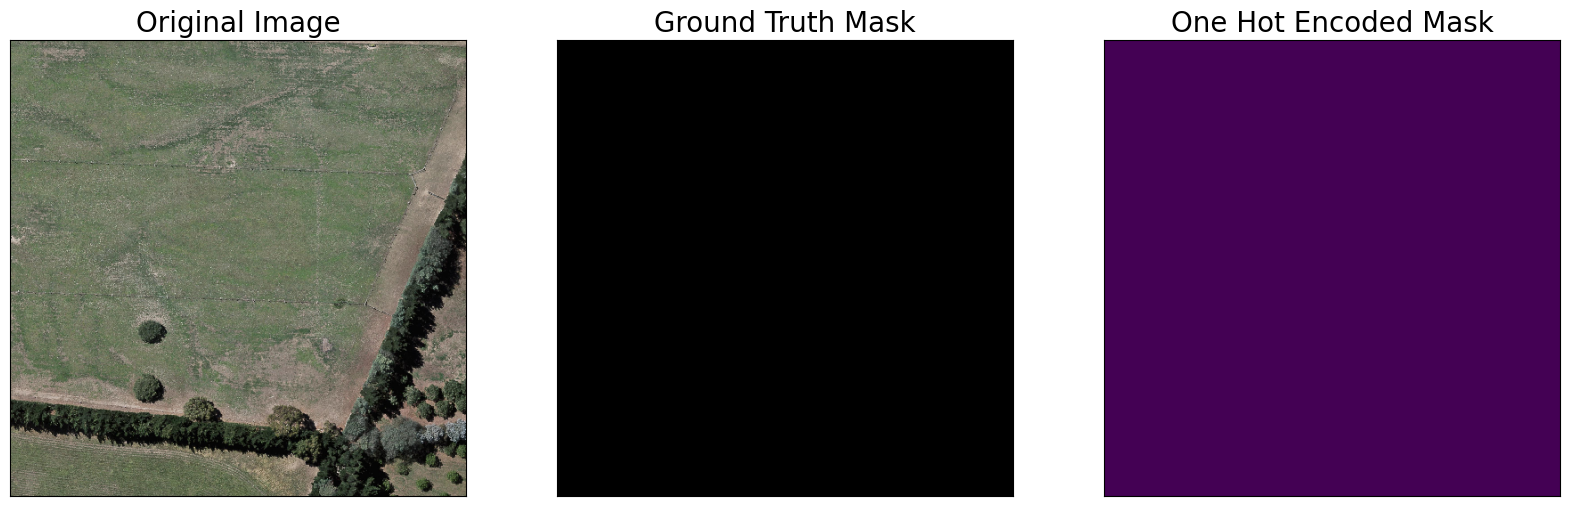

In [16]:

test_dataset = BuildingsDataset(
    x_test_dir, 
    y_test_dir, 
    svm_dir=svm_test_dir,  # ✅ اضافه شد
    augmentation=get_validation_augmentation(), 
    preprocessing=get_preprocessing(preprocessing_fn),
    class_rgb_values=select_class_rgb_values,
)

test_dataloader = DataLoader(test_dataset)

# دیتاست فقط برای نمایش (بدون preprocessing)
test_dataset_vis = BuildingsDataset(
    x_test_dir, 
    y_test_dir, 
    augmentation=get_validation_augmentation(),
    class_rgb_values=select_class_rgb_values,
)

# get a random test image/mask index
random_idx = random.randint(0, len(test_dataset_vis)-1)
image, mask = test_dataset_vis[random_idx]

visualize(
    original_image = image,
    ground_truth_mask = colour_code_segmentation(reverse_one_hot(mask), select_class_rgb_values),
    one_hot_encoded_mask = reverse_one_hot(mask)
)


In [12]:
def crop_image(image, target_image_dims=[5000, 5000, 3]):
    target_height, target_width = target_image_dims[:2]
    height, width = image.shape[:2]

    pad_top = (height - target_height) // 2
    pad_left = (width - target_width) // 2

    return image[
        pad_top : pad_top + target_height,
        pad_left : pad_left + target_width,
        :,
    ]


In [13]:
sample_preds_folder = 'sample_predictions/'
if not os.path.exists(sample_preds_folder):
    os.makedirs(sample_preds_folder)


In [14]:

import torch.nn.functional as F
import math

def pad_to_divisible(image_tensor, divisor=32):
    """Pads tensor so that height and width are divisible by `divisor`"""
    _, _, h, w = image_tensor.shape
    pad_h = math.ceil(h / divisor) * divisor - h
    pad_w = math.ceil(w / divisor) * divisor - w
    padded = F.pad(image_tensor, (0, pad_w, 0, pad_h))  # (left, right, top, bottom)
    return padded, (pad_h, pad_w)


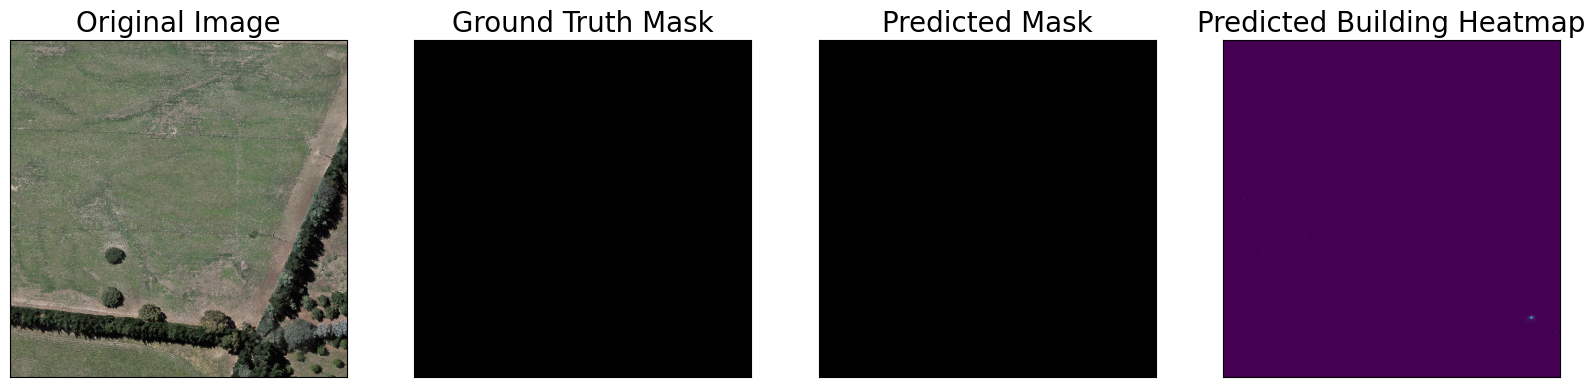

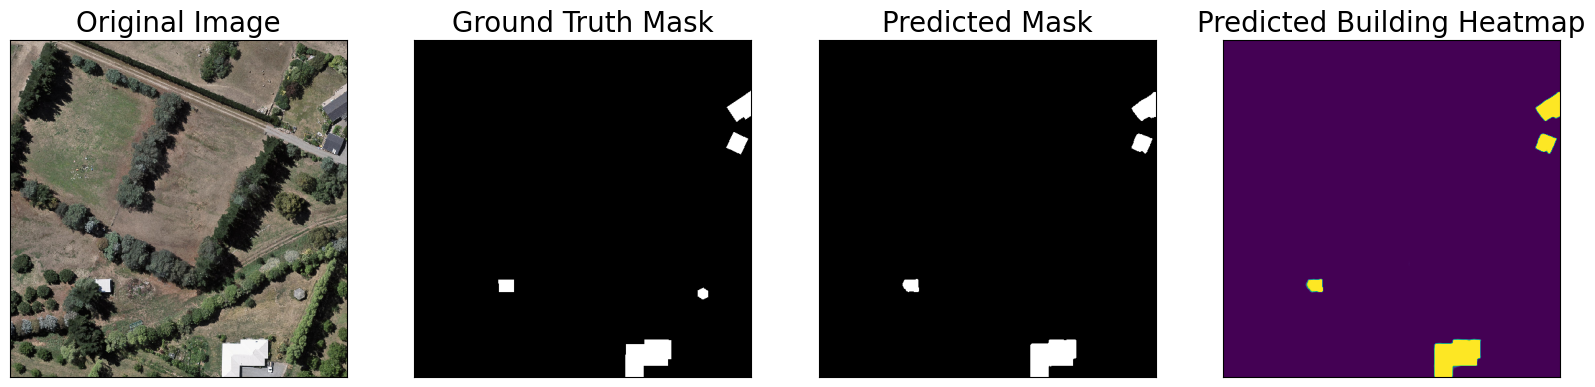

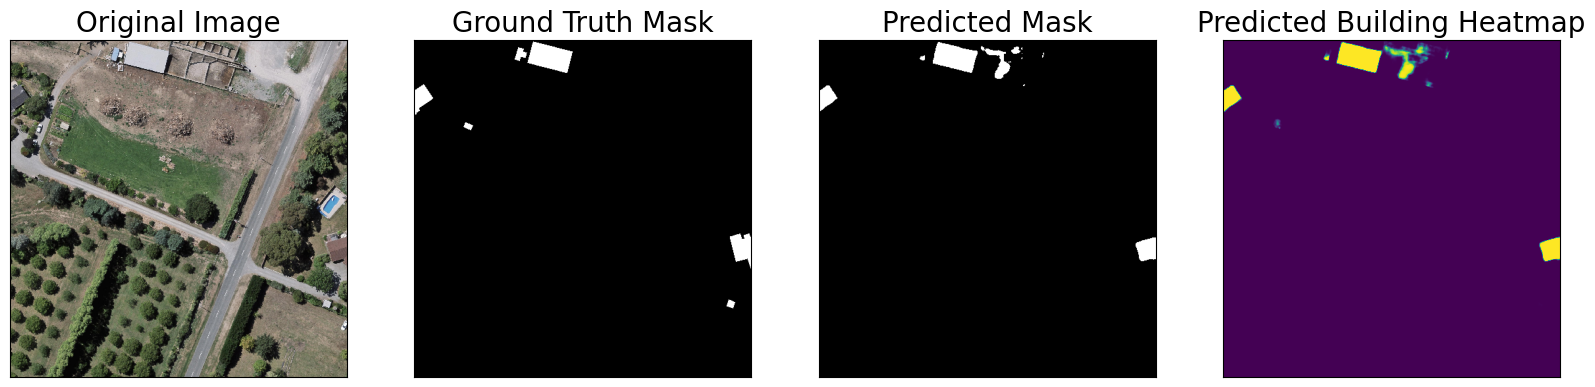

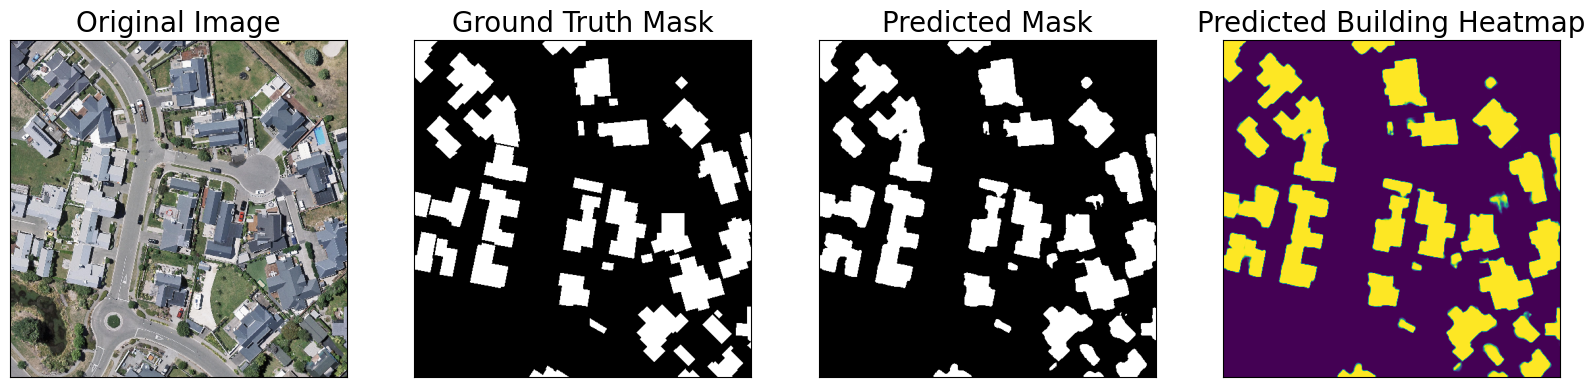

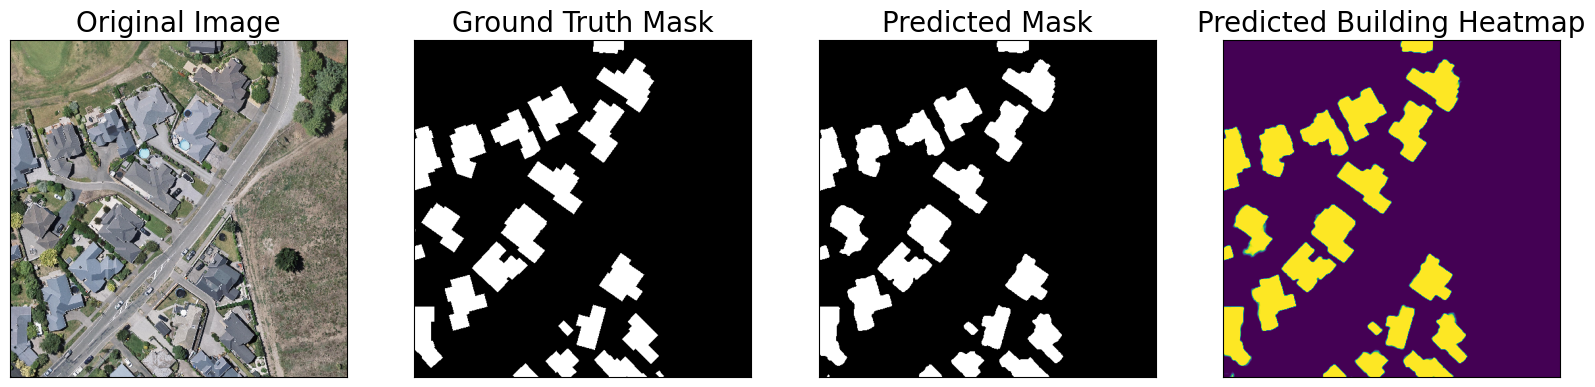

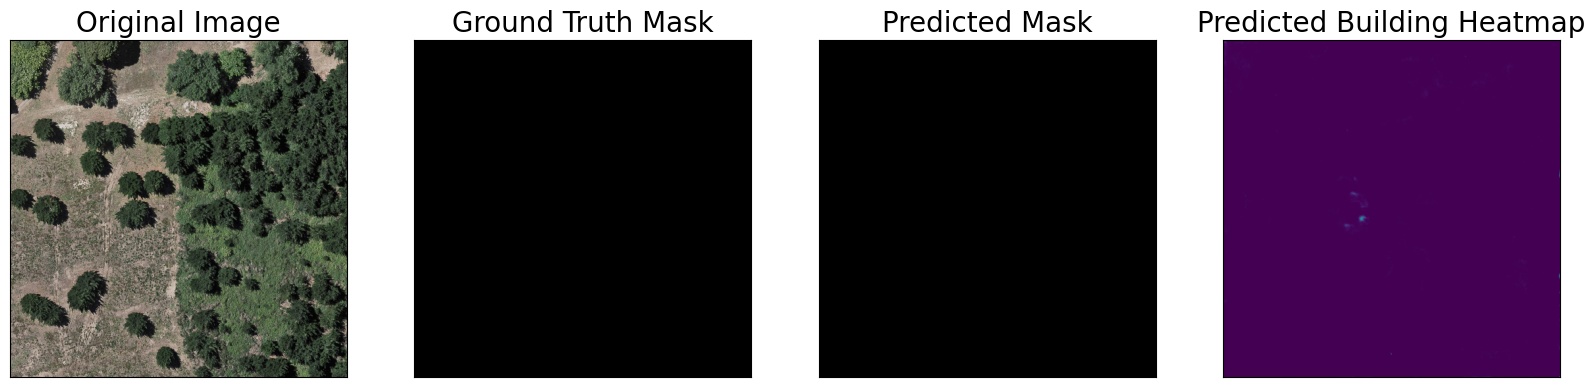

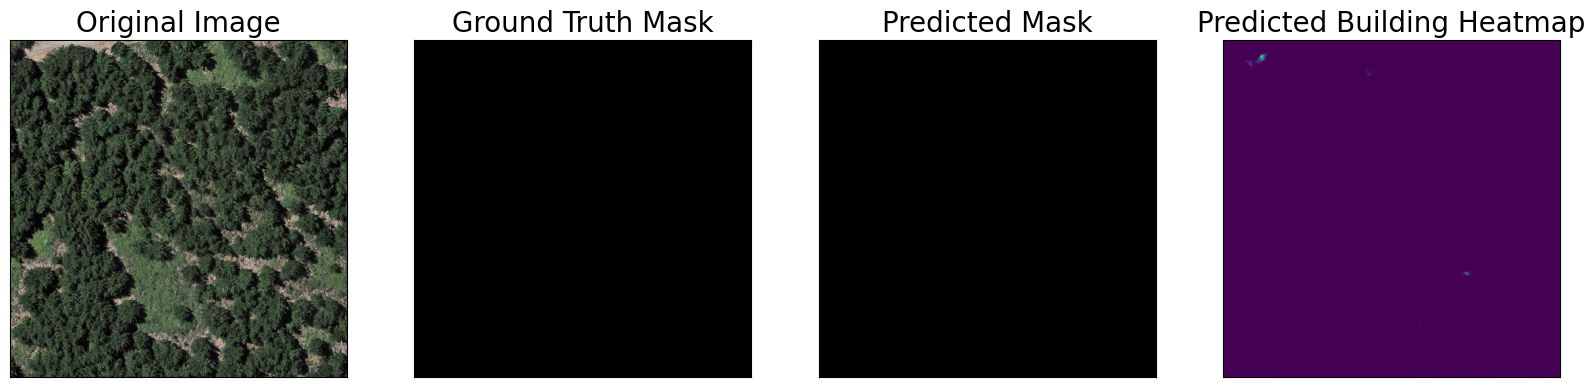

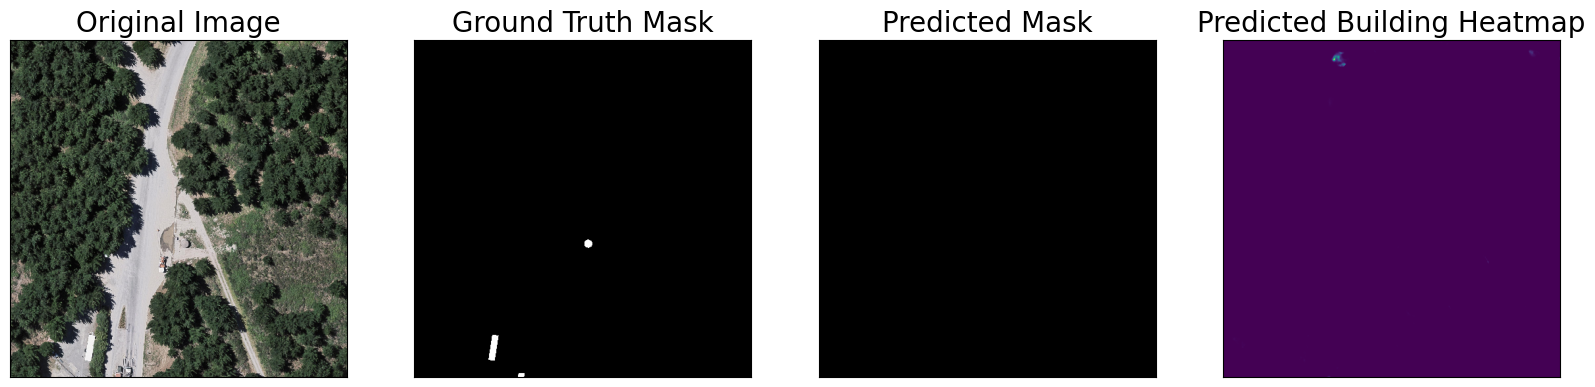

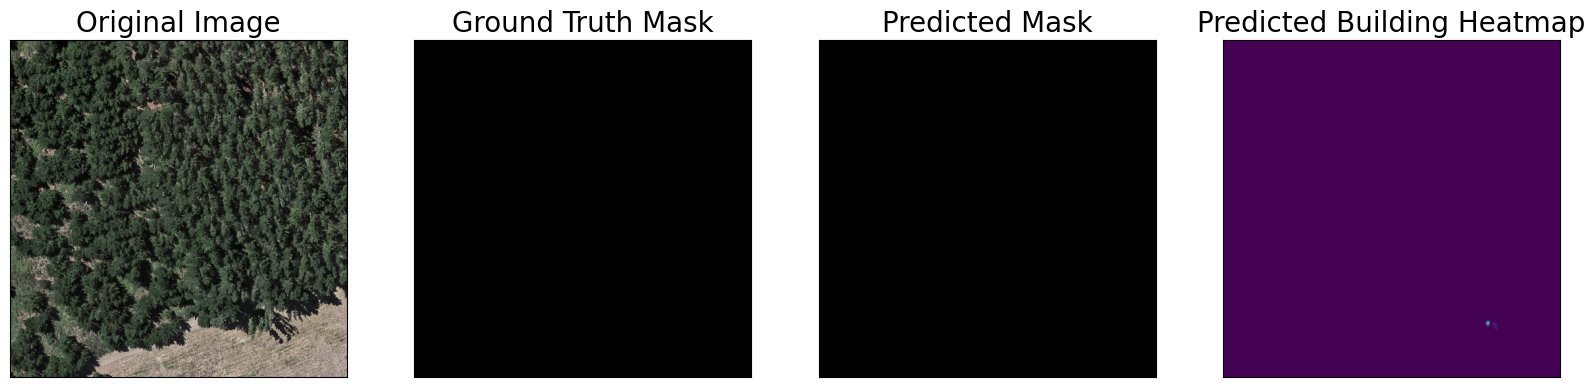

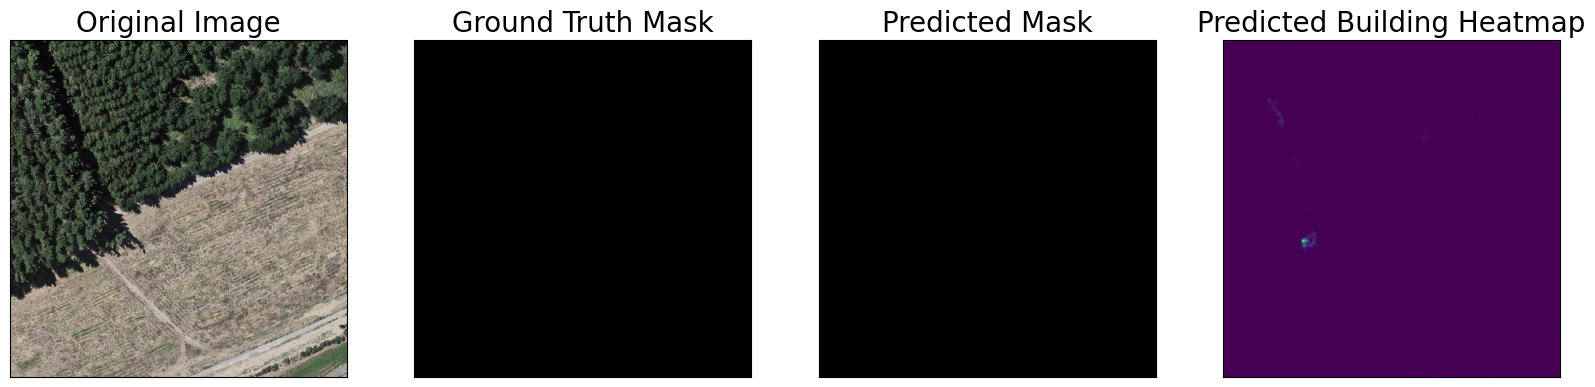

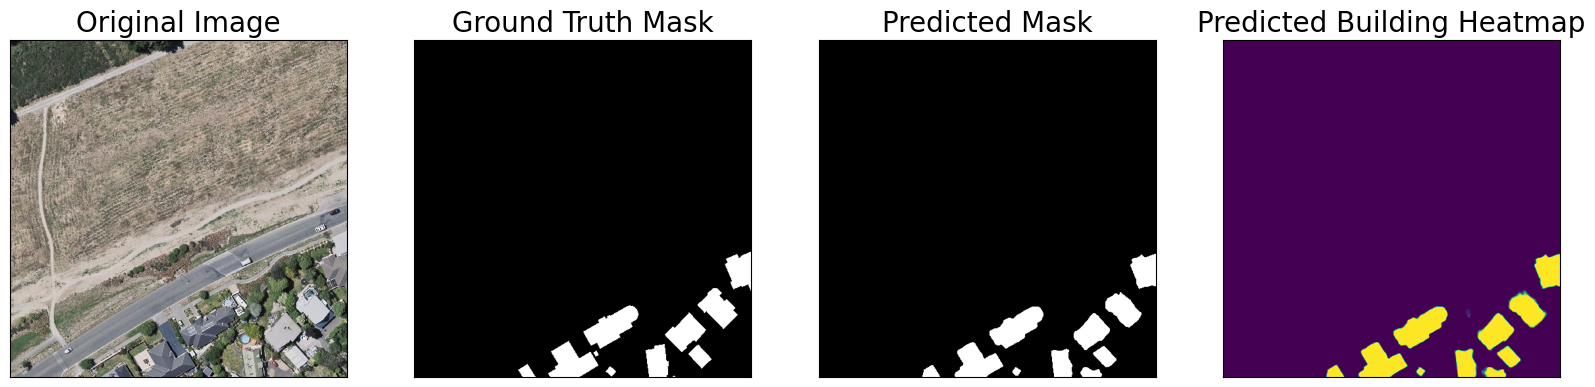

In [18]:
for idx in range(len(test_dataset)):
    sample = test_dataset[idx]
    if len(sample) == 3:
        image, gt_mask, svm_map = sample
        svm_tensor = torch.unsqueeze(svm_map, 0).to(DEVICE)  # [1, 1, H, W]
    else:
        image, gt_mask = sample
        svm_tensor = None
    image_vis = crop_image(test_dataset_vis[idx][0].astype('uint8'))
    x_tensor = torch.from_numpy(image).unsqueeze(0).to(DEVICE)  # [1, C, H, W]
    x_tensor, (pad_h, pad_w) = pad_to_divisible(x_tensor, divisor=32)
    if svm_tensor is not None:
        svm_tensor, _ = pad_to_divisible(svm_tensor, divisor=32)
    with torch.no_grad():
        if svm_tensor is not None:
            pred_mask = best_model(x_tensor, svm_map=svm_tensor)
        else:
            pred_mask = best_model(x_tensor)
    if pad_h > 0 or pad_w > 0:
        pred_mask = pred_mask[:, :, :-pad_h if pad_h > 0 else None, :-pad_w if pad_w > 0 else None]
    pred_mask = pred_mask.squeeze().cpu().numpy()
    pred_mask = np.transpose(pred_mask, (1, 2, 0))  # CHW → HWC
    pred_building_heatmap = pred_mask[:, :, select_classes.index('building')]

    pred_mask_rgb = crop_image(colour_code_segmentation(reverse_one_hot(pred_mask), select_class_rgb_values))

    gt_mask = np.transpose(gt_mask, (1, 2, 0))
    gt_mask_rgb = crop_image(colour_code_segmentation(reverse_one_hot(gt_mask), select_class_rgb_values))

    cv2.imwrite(
        os.path.join(sample_preds_folder, f"sample_pred_{idx}.png"),
        np.hstack([image_vis, gt_mask_rgb, pred_mask_rgb])[:, :, ::-1]  # BGR برای OpenCV
    )

    visualize(
        original_image=image_vis,
        ground_truth_mask=gt_mask_rgb,
        predicted_mask=pred_mask_rgb,
        predicted_building_heatmap=pred_building_heatmap
    )
